Bins Columns: Index(['BinID', 'Ward', 'AreaType', 'PopulationDensity', 'WasteType',
       'Capacity_Ltrs', 'Latitude', 'Longitude'],
      dtype='object')
Trucks Columns: Index(['TruckID', 'Model', 'FuelType', 'Specialization', 'FuelPerKm'], dtype='object')
Routes Columns: Index(['RouteID', 'BinID', 'TruckID', 'Sequence', 'Distance_KM'], dtype='object')

Sample Priority Calculation:
   BinID PopulationDensity  Capacity_Ltrs  Priority
0  B1000              High            500     2.700
1  B1001              High           1000     2.400
2  B1002              High            800     2.475
3  B1003              High            300     3.100
4  B1004            Medium            300     2.400

Important Bins:
    BinID  Priority
0   B1000     2.700
1   B1002     2.475
2   B1003     3.100
3   B1010     2.700
4   B1011     2.700
5   B1013     2.700
6   B1014     2.900
7   B1015     2.700
8   B1018     2.475
9   B1019     2.700
10  B1021     2.700
11  B1022     3.100
12  B1026     2.900
13  

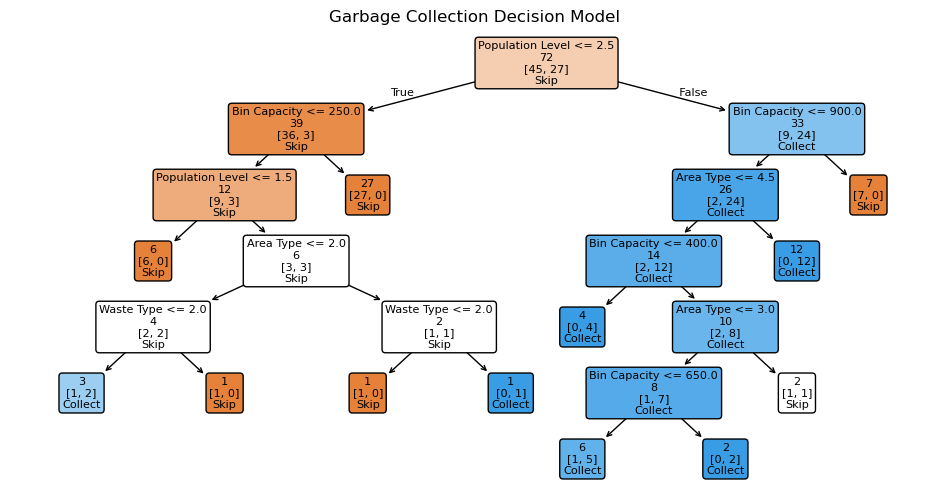

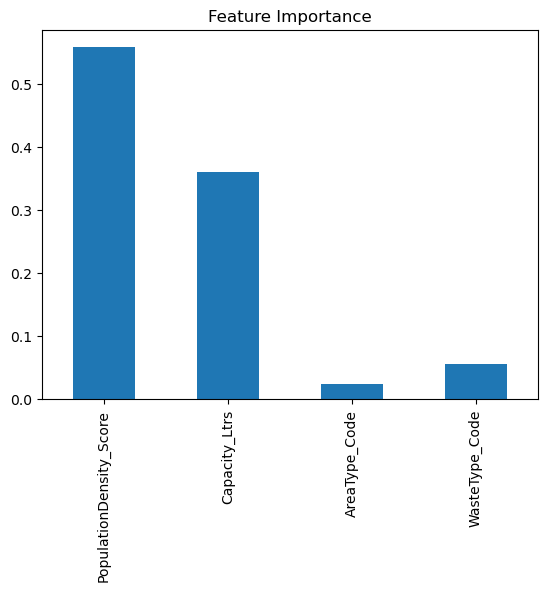

In [1]:
# ============================================================
# 🧠 SMART WASTE COLLECTION OPTIMIZATION PROJECT
# ============================================================
# Objective:
# - Prioritize garbage bins based on population & capacity
# - Assign bins to trucks
# - Generate optimized routes
# - Build ML model to predict collection priority
# ============================================================


# ============================================================
# 📦 1. IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from math import radians, sin, cos, sqrt, atan2
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree


# ============================================================
# 📂 2. LOAD DATASETS
# ============================================================
bins = pd.read_csv("Bins.csv")
trucks = pd.read_csv("Trucks.csv")
routes = pd.read_csv("Routes.csv")

print("Bins Columns:", bins.columns)
print("Trucks Columns:", trucks.columns)
print("Routes Columns:", routes.columns)


# ============================================================
# 📊 3. DATA PREPROCESSING & PRIORITY CALCULATION
# ============================================================

# Convert Population Density to numeric score
bins['PopulationDensity_Score'] = bins['PopulationDensity'].map({
    'Low': 1,
    'Medium': 2,
    'High': 3
})

# Priority Formula
bins['Priority'] = (
    bins['PopulationDensity_Score'] * 0.7 +
    (1000 / bins['Capacity_Ltrs']) * 0.3
)

print("\nSample Priority Calculation:")
print(bins[['BinID', 'PopulationDensity', 'Capacity_Ltrs', 'Priority']].head())


# ============================================================
# 🔥 4. SELECT IMPORTANT BINS
# ============================================================
important_bins = bins[bins['Priority'] > bins['Priority'].mean()]
important_bins = important_bins.reset_index(drop=True)

print("\nImportant Bins:")
print(important_bins[['BinID', 'Priority']])


# ============================================================
# 🌍 5. DISTANCE CALCULATION (HAVERSINE FORMULA)
# ============================================================
def distance(lat1, lon1, lat2, lon2):
    R = 6373.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

# Distance Matrix
distance_matrix = []

for i in range(len(important_bins)):
    row = []
    for j in range(len(important_bins)):
        dist = distance(
            important_bins.iloc[i]['Latitude'],
            important_bins.iloc[i]['Longitude'],
            important_bins.iloc[j]['Latitude'],
            important_bins.iloc[j]['Longitude']
        )
        row.append(dist)
    distance_matrix.append(row)

print("\nDistance Matrix Size:", len(distance_matrix))


# ============================================================
# 🚛 6. TRUCK ASSIGNMENT
# ============================================================
num_trucks = 5

important_bins['Truck_Assigned'] = [
    i % num_trucks for i in range(len(important_bins))
]

print("\nTruck Assignments:")
print(important_bins[['BinID', 'Truck_Assigned']].head())


# ============================================================
# 🛣️ 7. ROUTE OPTIMIZATION (NEAREST NEIGHBOR)
# ============================================================
def simple_route(indices, matrix):
    route = [indices[0]]
    visited = set(route)

    while len(route) < len(indices):
        last = route[-1]

        next_bin = min(
            [i for i in indices if i not in visited],
            key=lambda x: matrix[last][x]
        )

        route.append(next_bin)
        visited.add(next_bin)

    return route

# Generate Routes
all_routes = {}

for truck in range(num_trucks):
    bin_indices = important_bins[
        important_bins['Truck_Assigned'] == truck
    ].index.tolist()

    if len(bin_indices) > 1:
        route = simple_route(bin_indices, distance_matrix)
    else:
        route = bin_indices

    all_routes[truck] = route

# Print Routes
print("\nOptimized Routes:")
for truck, route in all_routes.items():
    bin_ids = [important_bins.iloc[i]['BinID'] for i in route]
    print(f"Truck {truck} route:", bin_ids)


# ============================================================
# 🤖 8. MACHINE LEARNING MODEL
# ============================================================

ml_data = bins.copy()

# Encode categorical features
ml_data['AreaType_Code'] = ml_data['AreaType'].map({
    'Residential': 1,
    'Commercial': 2,
    'Industrial': 3,
    'Hospital': 4,
    'Market': 5
})

ml_data['WasteType_Code'] = ml_data['WasteType'].map({
    'General': 1,
    'Organic': 2,
    'Recyclable': 3
})

# Target variable
ml_data['Target'] = (
    (ml_data['Priority'] > ml_data['Priority'].mean()) &
    (np.random.rand(len(ml_data)) > 0.2)
).astype(int)

# Features & Labels
X = ml_data[['PopulationDensity_Score', 'Capacity_Ltrs', 'AreaType_Code', 'WasteType_Code']]
y = ml_data['Target']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train Model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Accuracy
accuracy = model.score(X_test, y_test)
print("\nModel Accuracy:", accuracy)


# ============================================================
# 🌳 9. DECISION TREE VISUALIZATION
# ============================================================
plt.figure(figsize=(12,6))

plot_tree(
    model,
    feature_names=[
        'Population Level',
        'Bin Capacity',
        'Area Type',
        'Waste Type'
    ],
    class_names=['Skip', 'Collect'],
    filled=True,
    impurity=False,
    label='none',
    rounded=True
)

plt.title("Garbage Collection Decision Model")
plt.show()


# ============================================================
# 📈 10. FEATURE IMPORTANCE
# ============================================================
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()


# ============================================================
# ✅ END OF PROJECT
# ============================================================